<a href="https://colab.research.google.com/github/sreesreevallichowdary-png/eda-assignment/blob/main/eda_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

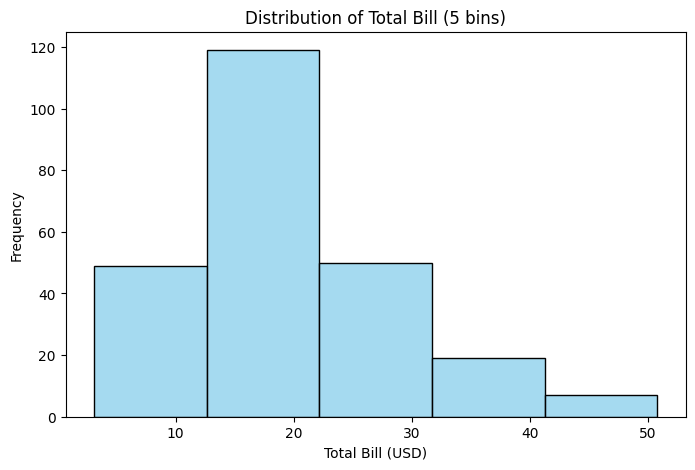

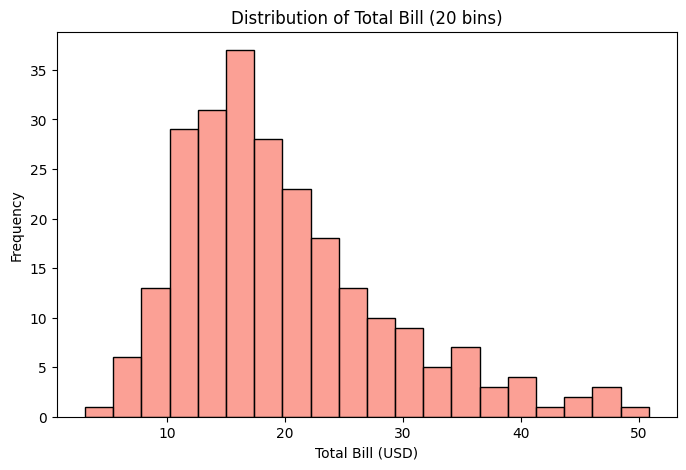

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

# Histogram with 5 bins
plt.figure(figsize=(8,5))
sns.histplot(df['total_bill'], bins=5, color='skyblue', edgecolor='black')
plt.title("Distribution of Total Bill (5 bins)")
plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.show()

# Histogram with 20 bins
plt.figure(figsize=(8,5))
sns.histplot(df['total_bill'], bins=20, color='salmon', edgecolor='black')
plt.title("Distribution of Total Bill (20 bins)")
plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.show()


-
- The total_bill distribution is right-skewed (long tail to the right). Most bills are in the lower range, with fewer very high bills.
- Effect of bin count:
- With 5 bins, the histogram is coarse — you see the general skew but lose detail.
- With 20 bins, the histogram is more granular — you can spot clusters, gaps, and subtle variations in bill amounts.

/tmp/ipykernel_483/3617392773.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day', y='total_bill', data=df, palette='Set2')


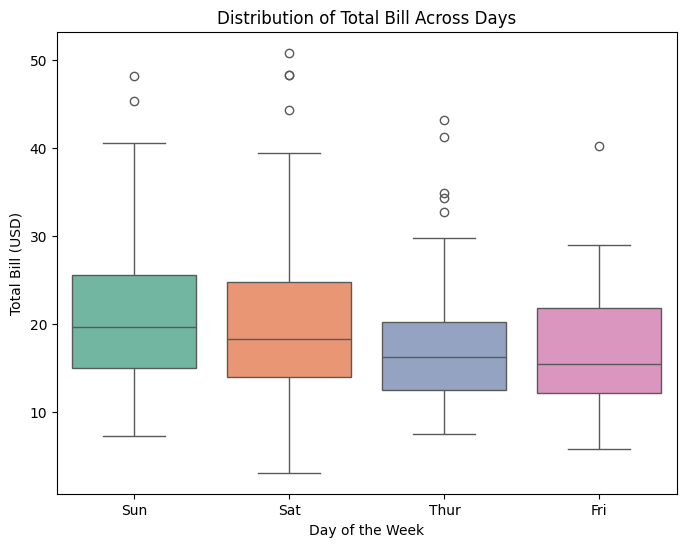

Sat Q1: 13.91, Q3: 24.74, IQR: 10.84
Lower Bound: -2.35, Upper Bound: 40.99
Outliers on Sat
     total_bill    tip  size
59        48.27   6.73     4
102       44.30   2.50     3
170       50.81  10.00     3
212       48.33   9.00     4


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

# Boxplot of total_bill across days
plt.figure(figsize=(8,6))
sns.boxplot(x='day', y='total_bill', data=df, palette='Set2')
plt.title("Distribution of Total Bill Across Days")
plt.xlabel("Day of the Week")
plt.ylabel("Total Bill (USD)")
plt.show()

# --- Outlier Detection Example ---
# Let's calculate IQR for Saturday
day = "Sat"
q1 = df[df['day'] == day]['total_bill'].quantile(0.25)
q3 = df[df['day'] == day]['total_bill'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"{day} Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")

# Identify outliers for Saturday
outliers = df[(df['day'] == day) &
              ((df['total_bill'] < lower_bound) | (df['total_bill'] > upper_bound))]

print("Outliers on", day)
print(outliers[['total_bill', 'tip', 'size']])






- Median comparison:
- From the boxplots, we will see which day has the highest median total_bill usually Saturday.
- Outliers:
- At least one day (often Saturday or Sunday) shows points outside the whiskers.
- By calculating Q1, Q3, and IQR, you can confirm whether those points qualify as outliers using the rule:
\mathrm{Outlier\  if\  }x<Q1-1.5\cdot IQR\quad \mathrm{or}\quad x>Q3+1.5\cdot IQR

In [4]:
import pandas as pd
import plotly.express as px

# Load dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

# Interactive scatter plot
fig = px.scatter(
    df,
    x="total_bill",
    y="tip",
    color="time",  # Lunch vs Dinner
    hover_data=["day", "size"],  # Show day and size on hover
    title="Relationship Between Total Bill and Tip (Colored by Meal Time)"
)

fig.show()


- Relationship between total_bill and tip:
- There is a positive relationship — as the total bill increases, tips generally increase too. However, the relationship is not perfectly proportional (larger bills don’t always mean proportionally larger tips).
- Lunch vs Dinner patterns:
- Dinner transactions (often shown in one color) tend to have higher bills and tips compared to Lunch.
- Lunch transactions cluster at lower bill values, suggesting smaller groups or lighter meals.
- Interesting data point:
- You might notice a very high bill with a relatively small tip (e.g., a bill above $50 but a tip under $5). This is unusual because tips usually scale with bill size.
- Hovering over that point reveals the day and group size, which can help explain whether it was a large group splitting unevenly or an anomaly